# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1.  Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2.  Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3.  Find out which national teams won the largest number of medals in the top five sports in 2016.
4.  Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## High-Level Steps

1.  Download the dataset and format it as a pandas DataFrame.
2.  Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
3.  Find out the medals awarded in 2016 for each sport.
4.  List the top five sports based on the largest number of medals awarded. Filter the DataFrame one more time to only include the records for the top five sports in 2016.
5.  Generate a bar plot of record counts corresponding to each of the top five sports.
6.  Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
7.  Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
8.  Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.

In [1]:
# 1. Download the dataset and format it as a pandas DataFrame.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
url = "https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/athlete_events.csv"
try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully.")
    print(df.head())
except Exception as e:
    print(f"Error loading dataset: {e}")


Dataset loaded successfully.
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lightweight   NaN

In [2]:
# 2. Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
# Note: The dataset might not have 2016 data if it's an older version. Let's check the years.
if 'df' in locals():
    print(df['Year'].unique())
    # If 2016 is not present, we might need to use the latest available year or a different dataset.
    # Based on the dataset description, it covers up to 2016.

    df_2016_medals = df[(df['Year'] == 2016) & (df['Medal'].notna())]
    print(f"Number of medal winners in 2016: {len(df_2016_medals)}")
    print(df_2016_medals.head())


[1992 2012 1920 1900 1988 1994 1932 2002 1952 1980 2000 1996 1912 1924
 2014 1948 1998 2006 2008 2016 2004 1960 1964 1984 1968 1972 1936 1956
 1928 1976 2010 1906 1904 1908 1896]
Number of medal winners in 2016: 2023
      ID                         Name Sex   Age  Height  Weight        Team  \
158   62            Giovanni Abagnale   M  21.0   198.0    90.0       Italy   
161   65            Patimat Abakarova   F  21.0   165.0    49.0  Azerbaijan   
175   73                    Luc Abalo   M  31.0   182.0    86.0      France   
450  250         Saeid Morad Abdevali   M  26.0   170.0    80.0        Iran   
794  455  Denis Mikhaylovich Ablyazin   M  24.0   161.0    62.0      Russia   

     NOC        Games  Year  Season            City       Sport  \
158  ITA  2016 Summer  2016  Summer  Rio de Janeiro      Rowing   
161  AZE  2016 Summer  2016  Summer  Rio de Janeiro   Taekwondo   
175  FRA  2016 Summer  2016  Summer  Rio de Janeiro    Handball   
450  IRI  2016 Summer  2016  Summer  Rio

In [3]:
# 3. Find out the medals awarded in 2016 for each sport.
if 'df_2016_medals' in locals() and not df_2016_medals.empty:
    medals_per_sport = df_2016_medals['Sport'].value_counts()
    print(medals_per_sport)


Sport
Athletics                192
Swimming                 191
Rowing                   144
Football                 106
Hockey                    99
Handball                  89
Cycling                   84
Canoeing                  82
Water Polo                78
Rugby Sevens              74
Wrestling                 72
Basketball                72
Volleyball                72
Gymnastics                66
Fencing                   65
Judo                      56
Boxing                    51
Weightlifting             45
Equestrianism             45
Shooting                  45
Sailing                   45
Diving                    36
Taekwondo                 32
Synchronized Swimming     32
Badminton                 24
Tennis                    24
Table Tennis              24
Archery                   24
Rhythmic Gymnastics       18
Beach Volleyball          12
Triathlon                  6
Modern Pentathlon          6
Trampolining               6
Golf                       6
Name: co

In [4]:
# 4. List the top five sports based on the largest number of medals awarded.
# Filter the DataFrame one more time to only include the records for the top five sports in 2016.
if 'medals_per_sport' in locals():
    top_5_sports = medals_per_sport.head(5).index.tolist()
    print(f"Top 5 sports: {top_5_sports}")

    df_top_5 = df_2016_medals[df_2016_medals['Sport'].isin(top_5_sports)]
    print(f"Records for top 5 sports: {len(df_top_5)}")


Top 5 sports: ['Athletics', 'Swimming', 'Rowing', 'Football', 'Hockey']
Records for top 5 sports: 732


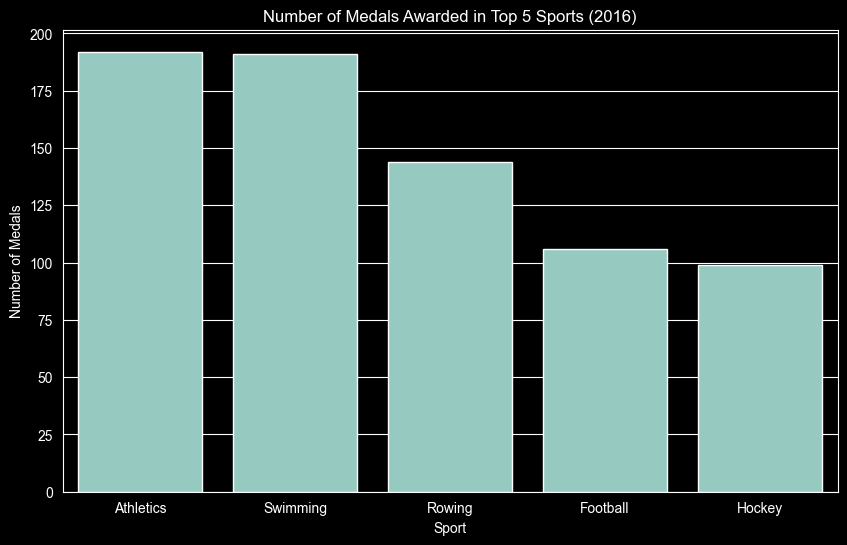

In [5]:
# 5. Generate a bar plot of record counts corresponding to each of the top five sports.
if 'df_top_5' in locals() and not df_top_5.empty:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_top_5, x='Sport', order=top_5_sports)
    plt.title('Number of Medals Awarded in Top 5 Sports (2016)')
    plt.xlabel('Sport')
    plt.ylabel('Number of Medals')
    plt.show()


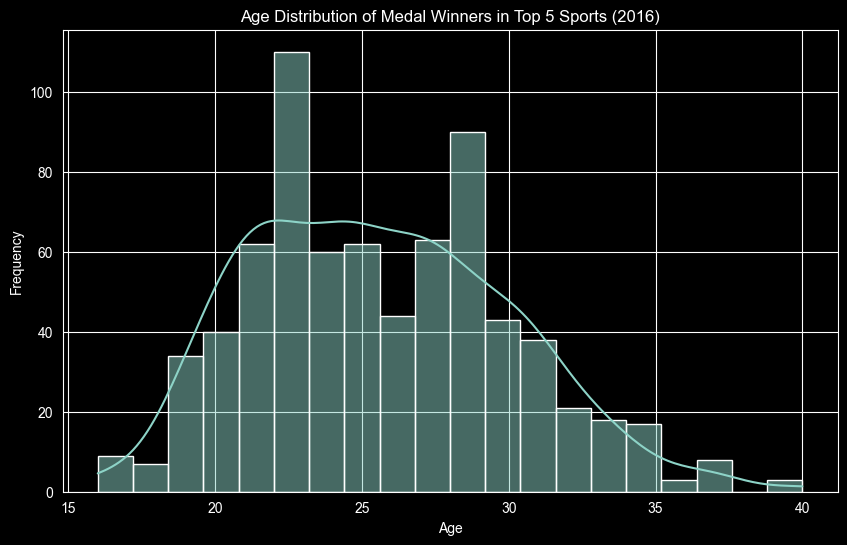

In [6]:
# 6. Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
if 'df_top_5' in locals() and not df_top_5.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_top_5, x='Age', bins=20, kde=True)
    plt.title('Age Distribution of Medal Winners in Top 5 Sports (2016)')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.show()


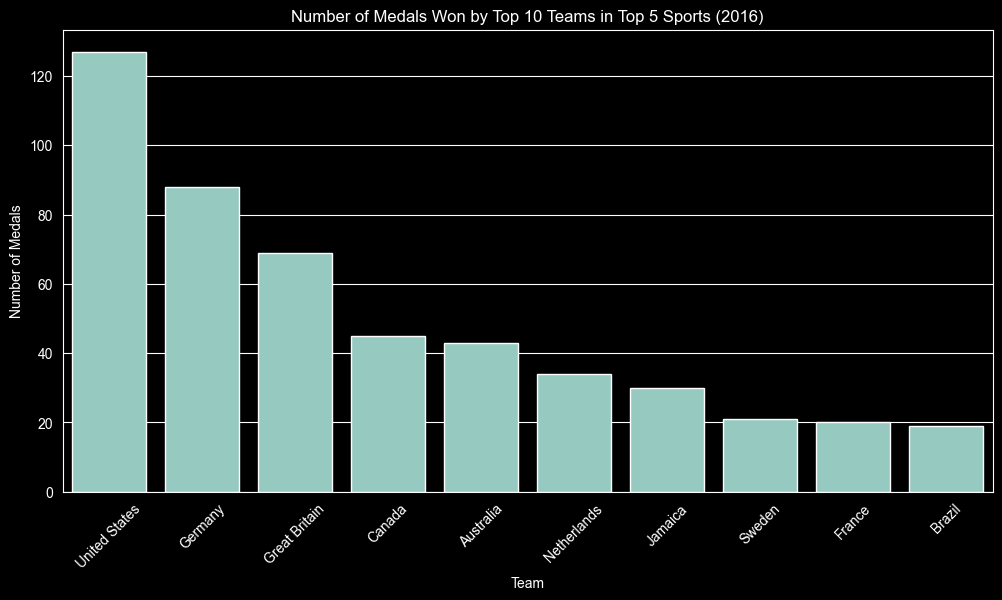

In [7]:
# 7. Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
if 'df_top_5' in locals() and not df_top_5.empty:
    # Let's look at the top 10 teams for better visualization
    top_teams = df_top_5['Team'].value_counts().head(10).index
    df_top_teams = df_top_5[df_top_5['Team'].isin(top_teams)]

    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_top_teams, x='Team', order=top_teams)
    plt.title('Number of Medals Won by Top 10 Teams in Top 5 Sports (2016)')
    plt.xlabel('Team')
    plt.ylabel('Number of Medals')
    plt.xticks(rotation=45)
    plt.show()


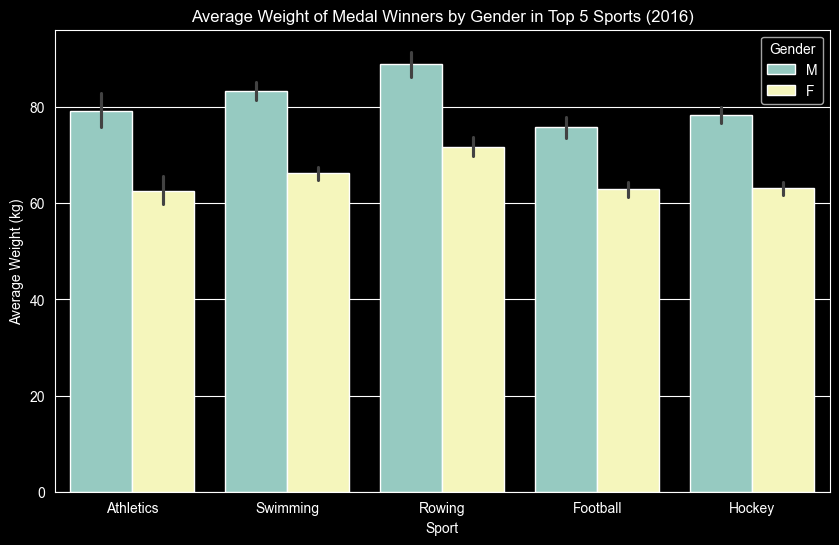

In [8]:
# 8. Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.
if 'df_top_5' in locals() and not df_top_5.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_top_5, x='Sport', y='Weight', hue='Sex', order=top_5_sports)
    plt.title('Average Weight of Medal Winners by Gender in Top 5 Sports (2016)')
    plt.xlabel('Sport')
    plt.ylabel('Average Weight (kg)')
    plt.legend(title='Gender')
    plt.show()
